# Data augmentation experiment

In [ ]:
# DATA_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob("*.wav"))))
print("Valid:", len(list(VALID_DIR.rglob("*.wav"))))

Train: 51486
Valid: 6828


In [ ]:
from pathlib import Path
import torch
import numpy as np
import random
import pandas as pd
import gc
import itertools

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig

from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed

from plots import (
    plot_f1_training_curves,
    build_summary_df,
    plot_summary_table,
    plot_metrics_comparison,
    plot_f1_comparison,
    plot_confusion_matrix
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [ ]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
LR = 3e-4
DROPOUT = 0.1
REPR = "mfcc"

In [ ]:
_, valid_ds, test_ds = get_datasets(
    data_format=REPR,
    train_path=TRAIN_DIR,
    valid_path=VALID_DIR,
    test_path=TEST_DIR,
)

In [ ]:
CACHE_DIR = Path("/kaggle/working/cache_aug_mfcc")

precompute_features(valid_ds, CACHE_DIR / "valid")
precompute_features(test_ds, CACHE_DIR / "test")

valid_ds_cached = CachedDataset(CACHE_DIR / "valid")
test_ds_cached = CachedDataset(CACHE_DIR / "test")

  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache_aug_mfcc/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache_aug_mfcc/test


In [ ]:
# different for train data

from data.transforms import FeatureConfig, MFCC, Normalize
from data.dataset import SpeechCommandsDataset, BackgroundNoiseDataset, Compose, AddBackgroundNoiseSNRDataset

feature_config = FeatureConfig()

mfcc_transform = Compose([
    MFCC(feature_config),
    Normalize()
])

train_raw_ds = SpeechCommandsDataset(TRAIN_DIR, cfg=feature_config, transform=None)
noise_ds = BackgroundNoiseDataset(NOISE_DIR, feature_config)

print(len(train_raw_ds))
print(len(noise_ds))

51486
6


In [ ]:
SNR_LEVELS = [None, 20, 10, 5]

In [ ]:
def cnn_transformer_factory_mfcc(dropout=0.1):
    return CNNTransformer(
        n_features=40,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [ ]:
AUG_SAVE_PATH = "/kaggle/working/augmentation_mfcc.csv"

def augmentation_experiment_mfcc(snr_levels, seeds=[0, 1, 2], epochs=30, batch_size=64, lr=3e-4, dropout=0.1):
    results = {}
    rows = []

    for snr in snr_levels:
        aug_name = "no_aug" if snr is None else f"snr_{snr}"
        results[aug_name] = {}

        print(f"\nPreparing train cache: {aug_name}")

        train_aug_ds = AddBackgroundNoiseSNRDataset(
            base_dataset=train_raw_ds,
            noise_dataset=noise_ds,
            feature_config=feature_config,
            feature_transform=mfcc_transform,
            snr_db=snr,
        )

        train_cache_path = CACHE_DIR / f"train_{aug_name}"
        precompute_features(train_aug_ds, train_cache_path)
        train_cached = CachedDataset(train_cache_path)

        for seed in seeds:
            print(f"\nAugmentation={aug_name} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory_mfcc(dropout=dropout).to(device)

            model, history = train(
                model,
                train_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                device=device,
            )

            preds_test, labels_test = predict(
                model,
                test_ds_cached,
                device=device,
                batch_size=batch_size,
            )

            test_result = evaluate(
                preds_test,
                labels_test,
                print_report=False,
            )

            results[aug_name][seed] = {
                "history": history,
                "valid_acc": max(history["valid_acc"]),
                "valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
                "test_cm": test_result["cm"],
            }

            rows.append({
                "augmentation": aug_name,
                "snr_db": snr,
                "seed": seed,
                "lr": lr,
                "batch_size": batch_size,
                "dropout": dropout,
                "best_valid_acc": max(history["valid_acc"]),
                "best_valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
            })

            pd.DataFrame(rows).to_csv(AUG_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return results, pd.DataFrame(rows)

In [ ]:
augmentation_results_mfcc, df_aug_mfcc = augmentation_experiment_mfcc(
    snr_levels=SNR_LEVELS,
    seeds=SEEDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    dropout=DROPOUT,
)

df_aug_mfcc.sort_values("test_macro_f1", ascending=False)


Preparing train cache: no_aug


  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_aug_mfcc/train_no_aug

Augmentation=no_aug | seed=0
Epoch 1/30 | Train Loss: 0.6239 | Valid Loss: 0.3286 | Valid Acc: 0.8944 | Valid Macro F1: 0.8380
Epoch 2/30 | Train Loss: 0.2127 | Valid Loss: 0.2110 | Valid Acc: 0.9332 | Valid Macro F1: 0.8985
Epoch 3/30 | Train Loss: 0.1572 | Valid Loss: 0.1980 | Valid Acc: 0.9405 | Valid Macro F1: 0.9077
Epoch 4/30 | Train Loss: 0.1291 | Valid Loss: 0.1868 | Valid Acc: 0.9439 | Valid Macro F1: 0.9111
Epoch 5/30 | Train Loss: 0.1069 | Valid Loss: 0.1656 | Valid Acc: 0.9495 | Valid Macro F1: 0.9203
Epoch 6/30 | Train Loss: 0.0939 | Valid Loss: 0.1851 | Valid Acc: 0.9455 | Valid Macro F1: 0.9182
Epoch 7/30 | Train Loss: 0.0817 | Valid Loss: 0.1715 | Valid Acc: 0.9525 | Valid Macro F1: 0.9287
Epoch 8/30 | Train Loss: 0.0743 | Valid Loss: 0.1560 | Valid Acc: 0.9545 | Valid Macro F1: 0.9257
Epoch 9/30 | Train Loss: 0.0637 | Valid Loss: 0.1610 | Valid Acc: 0.9565 | Valid Macro F1: 0.9352
Epoch 10/30 | Train L

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_aug_mfcc/train_snr_20

Augmentation=snr_20 | seed=0
Epoch 1/30 | Train Loss: 0.6875 | Valid Loss: 0.4045 | Valid Acc: 0.8692 | Valid Macro F1: 0.8033
Epoch 2/30 | Train Loss: 0.2707 | Valid Loss: 0.2582 | Valid Acc: 0.9174 | Valid Macro F1: 0.8661
Epoch 3/30 | Train Loss: 0.1932 | Valid Loss: 0.2704 | Valid Acc: 0.9156 | Valid Macro F1: 0.8682
Epoch 4/30 | Train Loss: 0.1564 | Valid Loss: 0.2660 | Valid Acc: 0.9219 | Valid Macro F1: 0.8747
Epoch 5/30 | Train Loss: 0.1335 | Valid Loss: 0.2483 | Valid Acc: 0.9174 | Valid Macro F1: 0.8763
Epoch 6/30 | Train Loss: 0.1156 | Valid Loss: 0.2584 | Valid Acc: 0.9266 | Valid Macro F1: 0.8799
Epoch 7/30 | Train Loss: 0.1022 | Valid Loss: 0.2675 | Valid Acc: 0.9227 | Valid Macro F1: 0.8843
Epoch 8/30 | Train Loss: 0.0891 | Valid Loss: 0.2593 | Valid Acc: 0.9282 | Valid Macro F1: 0.8801
Epoch 9/30 | Train Loss: 0.0760 | Valid Loss: 0.2388 | Valid Acc: 0.9359 | Valid Macro F1: 0.8998
Epoch 10/30 | Train L

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_aug_mfcc/train_snr_10

Augmentation=snr_10 | seed=0
Epoch 1/30 | Train Loss: 0.7760 | Valid Loss: 0.5411 | Valid Acc: 0.8226 | Valid Macro F1: 0.7425
Epoch 2/30 | Train Loss: 0.3327 | Valid Loss: 0.3724 | Valid Acc: 0.8840 | Valid Macro F1: 0.8099
Epoch 3/30 | Train Loss: 0.2558 | Valid Loss: 0.3251 | Valid Acc: 0.8979 | Valid Macro F1: 0.8413
Epoch 4/30 | Train Loss: 0.2040 | Valid Loss: 0.3246 | Valid Acc: 0.9028 | Valid Macro F1: 0.8450
Epoch 5/30 | Train Loss: 0.1749 | Valid Loss: 0.3421 | Valid Acc: 0.8948 | Valid Macro F1: 0.8514
Epoch 6/30 | Train Loss: 0.1489 | Valid Loss: 0.3774 | Valid Acc: 0.8950 | Valid Macro F1: 0.8282
Epoch 7/30 | Train Loss: 0.1312 | Valid Loss: 0.3214 | Valid Acc: 0.9057 | Valid Macro F1: 0.8536
Epoch 8/30 | Train Loss: 0.1155 | Valid Loss: 0.2929 | Valid Acc: 0.9161 | Valid Macro F1: 0.8619
Epoch 9/30 | Train Loss: 0.0986 | Valid Loss: 0.3127 | Valid Acc: 0.9214 | Valid Macro F1: 0.8734
Epoch 10/30 | Train L

In [ ]:
SNR_LEVELS_cd = [10, 5]

In [ ]:
def cnn_transformer_factory_mfcc(dropout=0.1):
    return CNNTransformer(
        n_features=40,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [ ]:
AUG_SAVE_PATH = "/kaggle/working/augmentation_mfcc_snr10_snr5.csv"

def augmentation_experiment_mfcc(snr_levels, seeds=[0, 1, 2], epochs=30, batch_size=64, lr=3e-4, dropout=0.1):
    results = {}
    rows = []

    for snr in snr_levels:
        aug_name = "no_aug" if snr is None else f"snr_{snr}"
        results[aug_name] = {}

        print(f"\nPreparing train cache: {aug_name}")

        train_aug_ds = AddBackgroundNoiseSNRDataset(
            base_dataset=train_raw_ds,
            noise_dataset=noise_ds,
            feature_config=feature_config,
            feature_transform=mfcc_transform,
            snr_db=snr,
        )

        train_cache_path = CACHE_DIR / f"train_{aug_name}"
        precompute_features(train_aug_ds, train_cache_path)
        train_cached = CachedDataset(train_cache_path)

        for seed in seeds:
            print(f"\nAugmentation={aug_name} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory_mfcc(dropout=dropout).to(device)

            model, history = train(
                model,
                train_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                device=device,
            )

            preds_test, labels_test = predict(
                model,
                test_ds_cached,
                device=device,
                batch_size=batch_size,
            )

            test_result = evaluate(
                preds_test,
                labels_test,
                print_report=False,
            )

            results[aug_name][seed] = {
                "history": history,
                "valid_acc": max(history["valid_acc"]),
                "valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
                "test_cm": test_result["cm"],
            }

            rows.append({
                "augmentation": aug_name,
                "snr_db": snr,
                "seed": seed,
                "lr": lr,
                "batch_size": batch_size,
                "dropout": dropout,
                "best_valid_acc": max(history["valid_acc"]),
                "best_valid_macro_f1": max(history["valid_f1"]),
                "test_acc": test_result["acc"],
                "test_macro_f1": test_result["macro_f1"],
                "test_weighted_f1": test_result["weighted_f1"],
            })

            pd.DataFrame(rows).to_csv(AUG_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return results, pd.DataFrame(rows)

In [ ]:
augmentation_results_mfcc_cd, df_aug_mfcc_cd = augmentation_experiment_mfcc(
    snr_levels=SNR_LEVELS_cd,
    seeds=SEEDS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    dropout=DROPOUT,
)

df_aug_mfcc_cd.sort_values("test_macro_f1", ascending=False)


Preparing train cache: snr_10


  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_aug_mfcc/train_snr_10

Augmentation=snr_10 | seed=0
Epoch 1/30 | Train Loss: 0.7767 | Valid Loss: 0.5765 | Valid Acc: 0.8037 | Valid Macro F1: 0.7302
Epoch 2/30 | Train Loss: 0.3306 | Valid Loss: 0.4008 | Valid Acc: 0.8760 | Valid Macro F1: 0.8011
Epoch 3/30 | Train Loss: 0.2476 | Valid Loss: 0.3121 | Valid Acc: 0.8997 | Valid Macro F1: 0.8415
Epoch 4/30 | Train Loss: 0.2072 | Valid Loss: 0.4330 | Valid Acc: 0.8686 | Valid Macro F1: 0.7684
Epoch 5/30 | Train Loss: 0.1689 | Valid Loss: 0.3946 | Valid Acc: 0.8824 | Valid Macro F1: 0.8185
Epoch 6/30 | Train Loss: 0.1495 | Valid Loss: 0.3564 | Valid Acc: 0.9026 | Valid Macro F1: 0.8411
Epoch 7/30 | Train Loss: 0.1295 | Valid Loss: 0.3213 | Valid Acc: 0.9019 | Valid Macro F1: 0.8520
Epoch 8/30 | Train Loss: 0.1162 | Valid Loss: 0.4122 | Valid Acc: 0.8944 | Valid Macro F1: 0.8210
Epoch 9/30 | Train Loss: 0.0998 | Valid Loss: 0.3728 | Valid Acc: 0.9022 | Valid Macro F1: 0.8469
Epoch 10/30 | Train L

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_aug_mfcc/train_snr_5

Augmentation=snr_5 | seed=0
Epoch 1/30 | Train Loss: 0.8765 | Valid Loss: 0.5434 | Valid Acc: 0.8159 | Valid Macro F1: 0.7186
Epoch 2/30 | Train Loss: 0.3938 | Valid Loss: 0.4419 | Valid Acc: 0.8606 | Valid Macro F1: 0.7639
Epoch 3/30 | Train Loss: 0.2990 | Valid Loss: 0.3836 | Valid Acc: 0.8793 | Valid Macro F1: 0.8043
Epoch 4/30 | Train Loss: 0.2455 | Valid Loss: 0.4358 | Valid Acc: 0.8757 | Valid Macro F1: 0.7950
Epoch 5/30 | Train Loss: 0.2071 | Valid Loss: 0.3881 | Valid Acc: 0.8796 | Valid Macro F1: 0.8126
Epoch 6/30 | Train Loss: 0.1788 | Valid Loss: 0.4320 | Valid Acc: 0.8798 | Valid Macro F1: 0.7892
Epoch 7/30 | Train Loss: 0.1545 | Valid Loss: 0.4578 | Valid Acc: 0.8727 | Valid Macro F1: 0.7944
Epoch 8/30 | Train Loss: 0.1364 | Valid Loss: 0.4405 | Valid Acc: 0.8828 | Valid Macro F1: 0.7990
Epoch 9/30 | Train Loss: 0.1158 | Valid Loss: 0.4380 | Valid Acc: 0.8846 | Valid Macro F1: 0.8170
Epoch 10/30 | Train Los

,augmentation,snr_db,seed,lr,batch_size,dropout,best_valid_acc,best_valid_macro_f1,test_acc,test_macro_f1,test_weighted_f1
2,snr_10,10,2,0.0003,64,0.1,0.929262,0.893311,0.918572,0.878102,0.916890
1,snr_10,10,1,0.0003,64,0.1,0.922086,0.880748,0.916096,0.869927,0.914191
0,snr_10,10,0,0.0003,64,0.1,0.920475,0.878250,0.914202,0.867285,0.911796
4,snr_5,5,1,0.0003,64,0.1,0.913152,0.859582,0.909832,0.852256,0.908121
5,snr_5,5,2,0.0003,64,0.1,0.910223,0.862185,0.904006,0.848834,0.901683
3,snr_5,5,0,0.0003,64,0.1,0.906561,0.842134,0.897014,0.834404,0.893494


In [ ]:
RESULTS_DIR = Path("../../results")

df_no_20 = pd.read_csv(RESULTS_DIR / "augmentation_mfcc_no_aug_snr_20.csv")
df_10_5 = pd.read_csv(RESULTS_DIR / "augmentation_mfcc_snr10_snr5.csv")

In [13]:
df_full = pd.concat([df_no_20, df_10_5], ignore_index=True)

In [14]:
df_full = df_full.sort_values("test_macro_f1", ascending=False)

df_full

,augmentation,snr_db,seed,lr,batch_size,dropout,best_valid_acc,best_valid_macro_f1,test_acc,test_macro_f1,test_weighted_f1
2,no_aug,NaN,2,0.0003,64,0.1,0.961482,0.943410,0.969556,0.956615,0.969474
1,no_aug,NaN,1,0.0003,64,0.1,0.962068,0.943510,0.969556,0.956202,0.969413
0,no_aug,NaN,0,0.0003,64,0.1,0.961629,0.943246,0.967808,0.953499,0.967628
3,snr_20,20.0,0,0.0003,64,0.1,0.947422,0.920210,0.950036,0.925144,0.949448
5,snr_20,20.0,2,0.0003,64,0.1,0.950937,0.926522,0.945958,0.920648,0.945256
4,snr_20,20.0,1,0.0003,64,0.1,0.947276,0.921309,0.945084,0.916595,0.944403
8,snr_10,10.0,2,0.0003,64,0.1,0.929262,0.893311,0.918572,0.878102,0.916890
7,snr_10,10.0,1,0.0003,64,0.1,0.922086,0.880748,0.916096,0.869927,0.914191
6,snr_10,10.0,0,0.0003,64,0.1,0.920475,0.878250,0.914202,0.867285,0.911796
10,snr_5,5.0,1,0.0003,64,0.1,0.913152,0.859582,0.909832,0.852256,0.908121


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

AUG_ORDER = ["no_aug", "snr_20", "snr_10", "snr_5"]
AUG_COLORS = sns.color_palette("deep", n_colors=len(AUG_ORDER))

df_full["augmentation"] = pd.Categorical(
    df_full["augmentation"],
    categories=AUG_ORDER,
    ordered=True,
)

/var/folders/47/pk5hn1dn45x1wrcdnc7ztmw40000gn/T/ipykernel_90362/374809029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


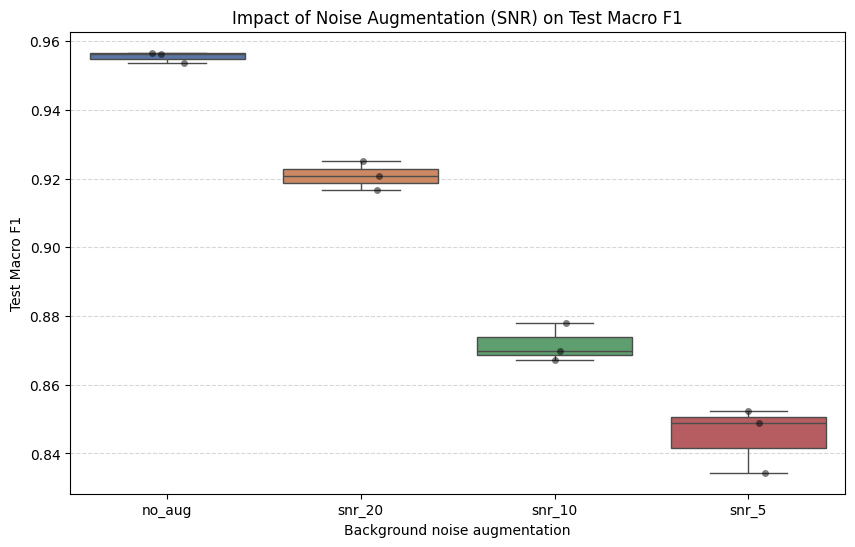

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_full,
    x="augmentation",
    y="test_macro_f1",
    order=AUG_ORDER,
    palette=AUG_COLORS,
)

sns.stripplot(
    data=df_full,
    x="augmentation",
    y="test_macro_f1",
    order=AUG_ORDER,
    color="black",
    alpha=0.5,
    size=5,
)

plt.title("Impact of Noise Augmentation (SNR) on Test Macro F1")
plt.xlabel("Background noise augmentation")
plt.ylabel("Test Macro F1")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

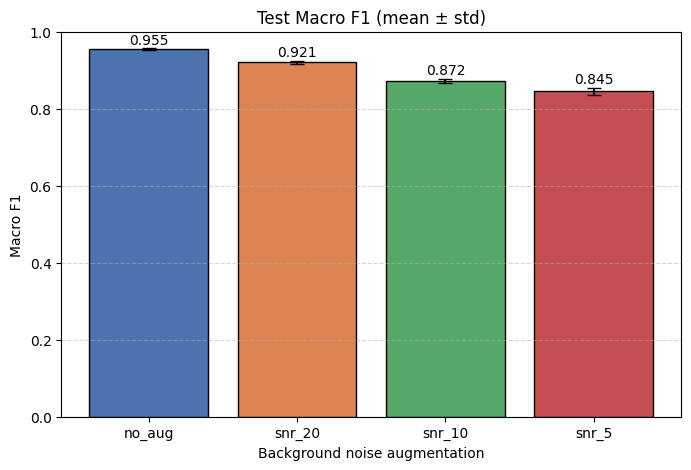

In [19]:
summary_aug = (
    df_full
    .groupby("augmentation", observed=False)
    .agg(
        mean=("test_macro_f1", "mean"),
        std=("test_macro_f1", "std")
    )
    .reset_index()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_aug["augmentation"].astype(str),
    summary_aug["mean"],
    yerr=summary_aug["std"],
    capsize=5,
    edgecolor="black",
    color=AUG_COLORS
)

for bar, (_, row) in zip(bars, summary_aug.iterrows()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        row["mean"] + row["std"] + 0.003,
        f"{row['mean']:.3f}",
        ha="center",
        va="bottom"
    )

plt.title("Test Macro F1 (mean ± std)")
plt.xlabel("Background noise augmentation")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()